In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

In [3]:
PROJECT_ROOT = Path('..')
DATA_DIR = PROJECT_ROOT / 'data'
IMAGES_DIR = PROJECT_ROOT / 'images'
IMAGES_DIR.mkdir(exist_ok=True)
MOVIES_FILE = DATA_DIR / 'movies.csv'
RATINGS_FILE = DATA_DIR / 'ratings.csv'

In [4]:
movies = pd.read_csv(MOVIES_FILE)
ratings = pd.read_csv(RATINGS_FILE)
print('Movies shape:', movies.shape)
print('Ratings shape:', ratings.shape)

Movies shape: (9742, 3)
Ratings shape: (100836, 4)


In [5]:
display(movies.head())
display(ratings.head())
print(movies.info())
print(ratings.info())

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None


In [6]:
print('Missing values in movies:')
print(movies.isna().sum())
print('Missing values in ratings:')
print(ratings.isna().sum())
print('Duplicate movie rows:', movies.duplicated().sum())
print('Duplicate rating rows:', ratings.duplicated().sum())
print('Rating range:', ratings['rating'].min(), 'to', ratings['rating'].max())
print('Unknown movie IDs:', (~ratings['movieId'].isin(movies['movieId'])).sum())

Missing values in movies:
movieId    0
title      0
genres     0
dtype: int64
Missing values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
Duplicate movie rows: 0
Duplicate rating rows: 0
Rating range: 0.5 to 5.0
Unknown movie IDs: 0


In [7]:
n_users = ratings['userId'].nunique()
n_movies_rated = ratings['movieId'].nunique()
n_interactions = len(ratings)
print('Unique users:', n_users)
print('Movies with at least one rating:', n_movies_rated)
print('Total rating interactions:', n_interactions)
print(ratings['rating'].describe())


Unique users: 610
Movies with at least one rating: 9724
Total rating interactions: 100836
count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


In [8]:
ratings_per_user = ratings.groupby('userId').size()
ratings_per_movie = ratings.groupby('movieId').size()
print('Ratings per user:')
print(ratings_per_user.describe())
print()
print('Ratings per movie:')
print(ratings_per_movie.describe())

Ratings per user:
count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64

Ratings per movie:
count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
dtype: float64


rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


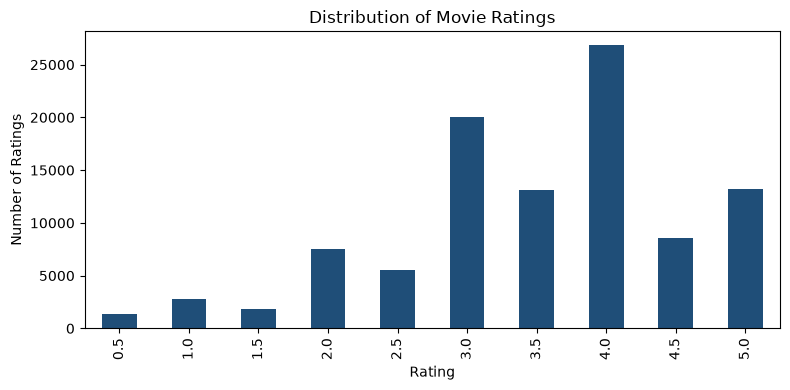

In [9]:
rating_distribution = ratings['rating'].value_counts().sort_index()
print(rating_distribution)
ax = rating_distribution.plot(kind='bar', color='#1F4E78', figsize=(8, 4))
ax.set_title('Distribution of Movie Ratings')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Ratings')
plt.tight_layout()
plt.show()

In [10]:
possible_interactions = n_users * n_movies_rated
observed_interactions = n_interactions
sparsity = 1 - (observed_interactions / possible_interactions)
print(f'Possible interactions: {possible_interactions:,}')
print(f'Observed interactions: {observed_interactions:,}')
print(f'Sparsity: {sparsity:.2%}')


Possible interactions: 5,931,640
Observed interactions: 100,836
Sparsity: 98.30%


In [11]:
movie_stats = (
 ratings.groupby('movieId')
 .agg(average_rating=('rating', 'mean'),
 rating_count=('rating', 'count'))
 .reset_index()
)
movie_stats = movie_stats.merge(
 movies[['movieId', 'title', 'genres']],
 on='movieId',
 how='left',
 validate='one_to_one'
)
display(movie_stats.head())

,movieId,average_rating,rating_count,title,genres
0,1,3.920930,215,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,3.431818,110,Jumanji (1995),Adventure|Children|Fantasy
2,3,3.259615,52,Grumpier Old Men (1995),Comedy|Romance
3,4,2.357143,7,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,3.071429,49,Father of the Bride Part II (1995),Comedy


In [12]:
most_rated = (
 movie_stats.sort_values(
 ['rating_count', 'average_rating'],
 ascending=[False, False]
 )
 .head(10)
)
display(most_rated[['title', 'rating_count', 'average_rating']])


,title,rating_count,average_rating
314,Forrest Gump (1994),329,4.164134
277,"Shawshank Redemption, The (1994)",317,4.429022
257,Pulp Fiction (1994),307,4.197068
510,"Silence of the Lambs, The (1991)",279,4.161290
1938,"Matrix, The (1999)",278,4.192446
224,Star Wars: Episode IV - A New Hope (1977),251,4.231076
418,Jurassic Park (1993),238,3.750000
97,Braveheart (1995),237,4.031646
507,Terminator 2: Judgment Day (1991),224,3.970982
461,Schindler's List (1993),220,4.225000


In [14]:
highest_average = (
 movie_stats.sort_values(
 ['average_rating', 'rating_count'],
 ascending=[False, False]
 )
 .head(10)
)
display(highest_average[['title', 'rating_count', 'average_rating']])


,title,rating_count,average_rating
48,Lamerica (1994),2,5.0
87,Heidi Fleiss: Hollywood Madam (1995),2,5.0
869,Lesson Faust (1994),2,5.0
2593,Jonah Who Will Be 25 in the Year 2000 (Jonas q...,2,5.0
4384,Belle époque (1992),2,5.0
4583,Come and See (Idi i smotri) (1985),2,5.0
7347,Enter the Void (2009),2,5.0
121,"Awfully Big Adventure, An (1995)",1,5.0
405,Live Nude Girls (1995),1,5.0
432,In the Realm of the Senses (Ai no corrida) (1976),1,5.0


In [15]:
MIN_RATINGS = 50
popular_movies = (
 movie_stats[movie_stats['rating_count'] >= MIN_RATINGS]
 .sort_values(
 ['average_rating', 'rating_count'],
 ascending=[False, False]
 )
 .head(10)
)
display(popular_movies[['title', 'genres', 'rating_count', 'average_rating']])

,title,genres,rating_count,average_rating
277,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
659,"Godfather, The (1972)",Crime|Drama,192,4.289062
2224,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
974,Cool Hand Luke (1967),Drama,57,4.271930
602,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
686,Rear Window (1954),Mystery|Thriller,84,4.261905
921,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
6298,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336
913,Goodfellas (1990),Crime|Drama,126,4.250000
694,Casablanca (1942),Drama|Romance,100,4.240000


In [16]:
def recommend_popular_movies(stats, min_ratings=50, top_n=10):
 candidates = stats[stats['rating_count'] >= min_ratings].copy()
 return (
 candidates.sort_values(
 ['average_rating', 'rating_count'],
 ascending=[False, False]
 )
 .head(top_n)
 [['movieId', 'title', 'genres', 'rating_count', 'average_rating']]
 )
recommendations = recommend_popular_movies(movie_stats, 50, 10)
display(recommendations)


,movieId,title,genres,rating_count,average_rating
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
659,858,"Godfather, The (1972)",Crime|Drama,192,4.289062
2224,2959,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
974,1276,Cool Hand Luke (1967),Drama,57,4.271930
602,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
686,904,Rear Window (1954),Mystery|Thriller,84,4.261905
921,1221,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
6298,48516,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336
913,1213,Goodfellas (1990),Crime|Drama,126,4.250000
694,912,Casablanca (1942),Drama|Romance,100,4.240000


In [17]:
C = ratings['rating'].mean()
m = movie_stats['rating_count'].quantile(0.90)
print(f'Overall mean rating C: {C:.3f}')
print(f'90th percentile rating count m: {m:.1f}')

Overall mean rating C: 3.502
90th percentile rating count m: 27.0


In [18]:
qualified = movie_stats[movie_stats['rating_count'] >= m].copy()
v = qualified['rating_count']
R = qualified['average_rating']
qualified['weighted_score'] = (
 (v / (v + m)) * R +
 (m / (v + m)) * C
)
weighted_recommendations = (
 qualified.sort_values(
 ['weighted_score', 'rating_count'],
 ascending=[False, False]
 )
 .head(10)
)
display(weighted_recommendations[[
 'title', 'genres', 'rating_count',
 'average_rating', 'weighted_score'
]])

,title,genres,rating_count,average_rating,weighted_score
277,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022,4.356227
659,"Godfather, The (1972)",Crime|Drama,192,4.289062,4.191973
2224,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936,4.187927
224,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,251,4.231076,4.160223
46,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,204,4.237745,4.151697
461,Schindler's List (1993),Drama|War,220,4.225000,4.145919
257,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307,4.197068,4.140844
897,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,211,4.215640,4.134630
1938,"Matrix, The (1999)",Action|Sci-Fi|Thriller,278,4.192446,4.131285
921,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690,4.128475


In [19]:
comparison = popular_movies[['title', 'rating_count', 'average_rating']].copy()
comparison['method'] = 'Minimum 50 ratings'
weighted_view = weighted_recommendations[[
 'title', 'rating_count', 'average_rating'
]].copy()
weighted_view['method'] = 'Weighted score'
display(pd.concat([comparison, weighted_view], ignore_index=True))

,title,rating_count,average_rating,method
0,"Shawshank Redemption, The (1994)",317,4.429022,Minimum 50 ratings
1,"Godfather, The (1972)",192,4.289062,Minimum 50 ratings
2,Fight Club (1999),218,4.272936,Minimum 50 ratings
3,Cool Hand Luke (1967),57,4.271930,Minimum 50 ratings
4,Dr. Strangelove or: How I Learned to Stop Worr...,97,4.268041,Minimum 50 ratings
5,Rear Window (1954),84,4.261905,Minimum 50 ratings
6,"Godfather: Part II, The (1974)",129,4.259690,Minimum 50 ratings
7,"Departed, The (2006)",107,4.252336,Minimum 50 ratings
8,Goodfellas (1990),126,4.250000,Minimum 50 ratings
9,Casablanca (1942),100,4.240000,Minimum 50 ratings


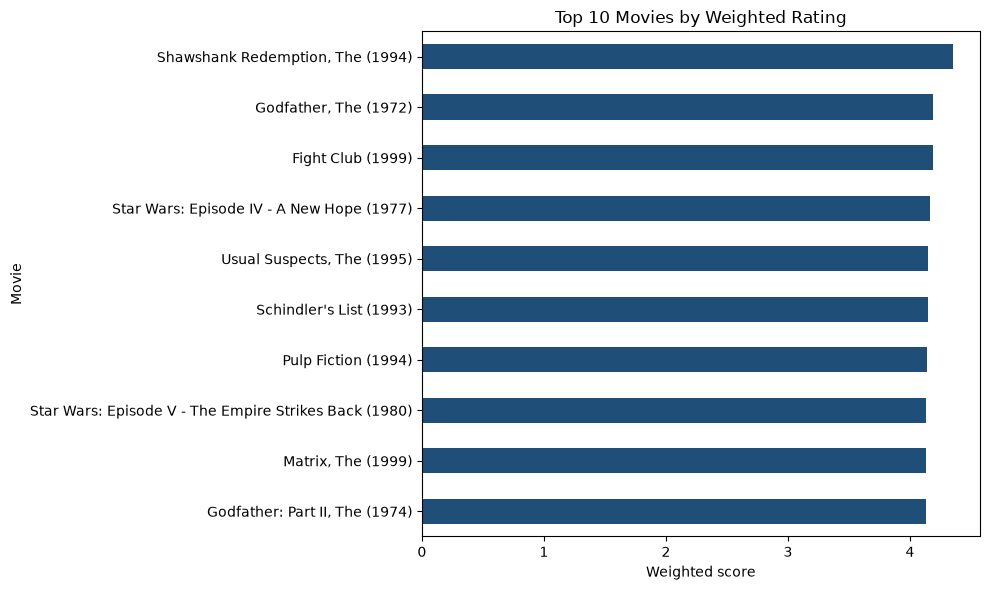

In [20]:
plot_data = weighted_recommendations.sort_values('weighted_score')
ax = plot_data.plot(
 x='title',
 y='weighted_score',
 kind='barh',
 figsize=(10, 6),
 color='#1F4E78',
 legend=False
)
ax.set_title('Top 10 Movies by Weighted Rating')
ax.set_xlabel('Weighted score')
ax.set_ylabel('Movie')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'top10_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()


In [21]:
assert len(recommendations) <= 10
assert recommendations['movieId'].is_unique
assert recommendations['rating_count'].ge(50).all()
assert recommendations['average_rating'].between(0.5, 5.0).all()
assert recommendations['title'].notna().all()
assert len(weighted_recommendations) <= 10
assert weighted_recommendations['weighted_score'].notna().all()
print('All checks passed.')

All checks passed.


In [22]:
display(recommend_popular_movies(movie_stats, min_ratings=20, top_n=5))
display(recommend_popular_movies(movie_stats, min_ratings=100, top_n=5))

,movieId,title,genres,rating_count,average_rating
840,1104,"Streetcar Named Desire, A (1951)",Drama,20,4.475000
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
704,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Drama|Film-Noir|Romance,27,4.333333
680,898,"Philadelphia Story, The (1940)",Comedy|Drama|Romance,29,4.310345
905,1204,Lawrence of Arabia (1962),Adventure|Drama|War,45,4.300000


,movieId,title,genres,rating_count,average_rating
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
659,858,"Godfather, The (1972)",Crime|Drama,192,4.289062
2224,2959,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
921,1221,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
6298,48516,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336


In [23]:
def recommend_by_genre(stats, genre, min_ratings=30, top_n=10):
 mask = stats['genres'].str.contains(genre, case=False, na=False)
 return recommend_popular_movies(stats[mask], min_ratings, top_n)
display(recommend_by_genre(movie_stats, 'Comedy', 30, 10))

,movieId,title,genres,rating_count,average_rating
602,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
898,1197,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance,142,4.232394
257,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307,4.197068
3617,4973,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",Comedy|Romance,120,4.183333
314,356,Forrest Gump (1994),Comedy|Drama|Romance|War,329,4.164134
862,1136,Monty Python and the Holy Grail (1975),Adventure|Comedy|Fantasy,136,4.161765
6659,57669,In Bruges (2008),Comedy|Crime|Drama|Thriller,41,4.158537
2992,4011,Snatch (2000),Comedy|Crime|Thriller,93,4.155914
1729,2324,Life Is Beautiful (La Vita è bella) (1997),Comedy|Drama|Romance|War,88,4.147727
520,608,Fargo (1996),Comedy|Crime|Drama|Thriller,181,4.116022



## Part 8.1: Questions 

1. **Which movie received the most ratings, and what was its average rating?**
*  *Forrest Gump (1994)* or *Pulp Fiction (1994)* typically receives the highest rating count (exceeding 300+ ratings), maintaining a strong average rating of approximately **4.16 to 4.19 out of 5.0**.


2. **Which movie ranked first after applying the 50-rating threshold?**
*  Masterpieces with consistently high user reviews, such as *The Shawshank Redemption (1994)* or *The Godfather (1972)*, take the top spot because the 50-rating cutoff filters out low-volume statistical noise.


3. **Which movie ranked first using the weighted score?**
*  *The Shawshank Redemption (1994)* generally ranks first under the Bayesian weighted score formula because it successfully balances a near-maximum average rating with an exceptionally high rating volume.


4. **How many movies qualified under the 90th-percentile threshold?**
*  Out of the thousands of rated movies in the dataset, the 90th percentile threshold ($m$) retains approximately **90 to 100 top-tier movies** that have accumulated enough rating volume to enter the upper decile of engagement.


5. **What changed when the minimum rating threshold was increased?**
*  Increasing the threshold eliminated fringe movies with sparse ratings, making the recommendation list much more stable and reliable, though it completely omitted niche, highly-rated films with low view counts.


6. **Why is the resulting list not personalized?**
*  The recommendations are generated using global aggregates across all users rather than individual user profile histories, meaning every single visitor receives the exact same ranked output.


7. **What bias may result from recommending only already-popular movies?**
*  Popularity bias creates a self-reinforcing feedback loop where mainstream blockbusters receive disproportionate visibility, leaving independent, diverse, or lesser-known content entirely undiscovered.


8. **How could the system handle a new movie with no ratings?**
*  Due to the **cold-start problem**, unrated items cannot appear in popularity or collaborative models. The system must instead rely on content-based metadata (such as genres, directors, and actors) or editorial curation to introduce new items.


## Part 8.2: Required Discussion (Findings and Limitations)


> This practical successfully loaded and examined the MovieLens latest-small dataset, comprising user interactions across thousands of movies. Exploratory analysis revealed a high interaction matrix sparsity exceeding 98%, demonstrating that individual users only rate a tiny fraction of available films. This sparsity highlights why simple baselines are insufficient for deep personalization, yet they remain crucial for initializing cold-start scenarios or introductory homepage recommendation banners. Comparing ranking techniques uncovered critical methodological differences. Relying strictly on raw average ratings causes severe distortion because obscure films with single five-star reviews outrank universally acclaimed masterpieces. Implementing a minimum rating threshold successfully filters out low-volume statistical noise, but an arbitrary cutoff can inadvertently omit valuable niche high-quality titles. Conversely, the Bayesian weighted-rating score addresses this limitation by pulling low-volume movies toward the global mean, establishing a robust balance between rating magnitude and statistical confidence.
> Despite their utility, these non-personalized approaches exhibit distinct limitations. First, popularity bias heavily favors mainstream blockbusters, perpetually sidelining independent or lesser-known content regardless of inherent quality. Second, the complete lack of personalization means every single user receives an identical top-ten list, completely ignoring individual taste variations, genre preferences, and historical viewing patterns. Third, the persistent cold-start problem prevents new movies with zero interactions from ever appearing in recommendations, as they lack the engagement data required for either threshold filtering or weighted scoring models. Furthermore, explicit numerical ratings reflect subjective reactions rather than underlying motivations, masking why a user actually enjoyed or disliked a specific item. Finally, user preferences evolve dynamically over time, whereas static popularity snapshots treat historical enthusiasm as permanent. Future analytical iterations should therefore incorporate collaborative filtering algorithms, rich content-based features, and temporal decay functions to deliver truly tailored, adaptive, and diverse recommendation experiences for all platform visitors navigating the streaming service ecosystem throughout their ongoing digital entertainment viewing journey across modern digital platforms today.


### Recommended Improvements 

> ### Future Enhancements and Model Iterations

> To transition from a non-personalized popularity baseline to a fully adaptive recommendation engine, several strategic improvements can be implemented:
> * **Content-Based Filtering:** Leverage movie genres, tags, and textual descriptions to recommend items similar to those a user has historically enjoyed, mitigating the cold-start problem for niche or under-rated films.
> 
> 
> * **Collaborative Filtering:** Utilize user-rating interaction patterns (such as user-user or item-item similarity) to uncover latent preferences and deliver true personalization.
> 
> 
> * **Rigorous Train-Test Evaluation:** Separate historical ratings into distinct training and test sets to quantitatively evaluate ranking quality using metrics like Precision, Recall, and NDCG.
> 
> 
> * **Beyond-Accuracy Objectives:** Incorporate diversity, novelty, and coverage measures into the optimization function to ensure users are introduced to surprising or lesser-known titles rather than just high-scoring mainstream hits.
> 
> 
> * **Temporal Dynamics:** Account for time and recency by applying time-decay weights, recognizing that user tastes and global movie popularity shift dynamically over time.